In [1]:
import numpy as np
import matplotlib.pyplot as plt

import sys

sys.path.insert(0, './my-src')
import post_production as pp

import seaborn as sns
from chainconsumer import ChainConsumer

In [2]:
def plot_corner_B(chain, sample, pop=None, save=None, annotate=None, xy=(200,200), limits=None):
    
    assert sample in ["N", "S", "joint"]
    
    if pop is not None:
        chain = np.delete(chain, pop, -1)
        
    if sample == "joint":
        f_nl = chain[:,0,:].flatten()
        b1N = chain[:,1,:].flatten()
        s_fogN = chain[:,2,:].flatten()
        NN = chain[:,3,:].flatten()
        b1S = chain[:,4,:].flatten()
        s_fogS = chain[:,5,:].flatten()
        NS = chain[:,6,:].flatten()
        
        data = np.vstack([f_nl, b1N, b1S]).transpose()
        labels=[r"$f_{\rm NL}$",
                r"$b_1\, (\rm NGC)$",
                r"$b_1\, (\rm SGC)$"]
        
    else:
        f_nl = chain[:,0,:].flatten()
        b1B = chain[:,1,:].flatten()
        b2 = chain[:,2,:].flatten()
        bs = chain[:,3,:].flatten()
        a1 = chain[:,4,:].flatten()
        a2 = chain[:,5,:].flatten()
        
        data = np.vstack([f_nl, b1B, b2, bs, a1, a2]).transpose()
        labels=[r"$f_{\rm NL}$",
                r"$b_1^B$",
                r"$b_2$",
                r"$b_{s2}$",
                r"$\alpha_1$",
                r"$\alpha_2$"]
        
    if limits is not None:
        assert len(limits) == len(labels)
        extents = {}
        for i,l in enumerate(labels):
            if limits[i] is None: continue
            extents[l] = limits[i]
    else: extents = None
        
    c = ChainConsumer()
    c.add_chain(data, parameters=labels)
    #modify kde for a different smoothing (the higher, the smoother)
    #summary area used to write summaries in the plot
    c.configure(kde=[2.1], usetex=True, diagonal_tick_labels=True, shade=[True], bar_shade=[False], summary = True,
               tick_font_size=15, label_font_size=20)
    fig = c.plotter.plot(figsize="column", extents=extents)
    
    #c = ChainConsumer()
    #c.add_chain(data1, parameters=labels, name="FKP")
    ##c.add_chain(data2, parameters=labels, name="Optimal")
    #c.configure(kde=[2.1, 2.1], usetex=True, diagonal_tick_labels=True, shade=[True], bar_shade=[False], summary = False)
    #fig = c.plotter.plot(figsize="column")

    #fig.set_size_inches(3 + fig.get_size_inches())

    if annotate is not None:
        plt.annotate(annotate, xy=xy, xycoords='axes pixels', fontsize=25)
    
    fig.set_size_inches(3 + fig.get_size_inches())
    
    if save is not None:
        plt.savefig(save, bbox_inches='tight')
    plt.show()
    

In [3]:
def plot_corner_B_prior(chain, pop=None, save=None, annotate=None, xy=(200,200)):
    
    if pop is not None:
        chain = np.delete(chain, pop, -1)
    
    f_nl = chain[:,0,:].flatten()
    b1B = chain[:,1,:].flatten()
    b2 = chain[:,2,:].flatten()
    bs = chain[:,3,:].flatten()
    a1 = chain[:,4,:].flatten()
    a2 = chain[:,5,:].flatten()
    
    data = np.vstack([f_nl, b1B, b2, bs, a1, a2]).transpose()
    labels=[r"$f_{\rm NL}$",
            r"$b_1^B$",
            r"$b_2$",
            r"$b_{s2}$",
            r"$\alpha_1$",
            r"$\alpha_2$"]
        
    nsample = 5000
    data2 = np.vstack([np.random.uniform(-1000, 1000, size=nsample),
                       np.random.normal(2.3, 0.5, size=nsample),
                       np.random.normal(-3.7, 5, size=nsample),
                       np.random.normal(-0.7, 0.6, size=nsample),
                       np.random.uniform(-1.5, 1.5, size=nsample),
                       np.random.uniform(-1.5, 1.5, size=nsample)]).transpose()    
    
    extents = {}
    for i,l in enumerate(labels):
        extents[l] = [data[:,i].min(), data[:,i].max()]
    #extents = None
    
    c = ChainConsumer()
    c.add_chain(data2, parameters=labels, name="Prior")
    c.add_chain(data, parameters=labels, name="Posterior")

    #modify kde for a different smoothing (the higher, the smoother)
    #summary area used to write summaries in the plot
    c.configure(kde=[2.1, 2.1], usetex=True, diagonal_tick_labels=True, shade=[True, True], bar_shade=[False, False], summary = True,
               tick_font_size=15, label_font_size=20)
    fig = c.plotter.plot(figsize="column", extents=extents)
    
    #c = ChainConsumer()
    #c.add_chain(data1, parameters=labels, name="FKP")
    c.add_chain(data2, parameters=labels, name="Prior")
    #c.configure(kde=[2.1, 2.1], usetex=True, diagonal_tick_labels=True, shade=[True], bar_shade=[False], summary = False)
    #fig = c.plotter.plot(figsize="column")

    #fig.set_size_inches(3 + fig.get_size_inches())

    if annotate is not None:
        plt.annotate(annotate, xy=xy, xycoords='axes pixels', fontsize=25)
    
    fig.set_size_inches(3 + fig.get_size_inches())
    
    if save is not None:
        plt.savefig(save, bbox_inches='tight')
    plt.show()
    

In [4]:
def plot_corner_PplusB(chain, sample, pop=None, save=None, annotate=None, xy=(200,200), limits=None):
    
    assert sample in ["N", "S", "joint"]
    
    if pop is not None:
        chain = np.delete(chain, pop, -1)
        
    if sample == "joint":
        f_nl = chain[:,0,:].flatten()
        b1N = chain[:,1,:].flatten()
        s_fogN = chain[:,5,:].flatten()
        NN = chain[:,6,:].flatten()
        b1S = chain[:,3,:].flatten()
        s_fogS = chain[:,7,:].flatten()
        NS = chain[:,8,:].flatten()
        
        b1BN = chain[:,2,:].flatten()
        b2N = chain[:,9,:].flatten()
        bsN = chain[:,10,:].flatten()
        c1N = chain[:,11,:].flatten()
        a1N = chain[:,12,:].flatten()
        a2N = chain[:,13,:].flatten()
        
        b1BS = chain[:,4,:].flatten()
        b2S = chain[:,14,:].flatten()
        bsS = chain[:,15,:].flatten()
        c1S = chain[:,16,:].flatten()
        a1S = chain[:,17,:].flatten()
        a2S = chain[:,18,:].flatten()
        
        data = np.vstack([f_nl, b1N, s_fogN, NN, b1S, s_fogS, NS]).transpose()
        labels=[r"$f_{\rm NL}$",
                r"$b_1\, (\rm NGC)$",
                r"$\sigma_{\rm FoG}\, (\rm NGC)$",
                r"$N\, (\rm NGC)$",
                r"$b_1\, (\rm SGC)$",
                r"$\sigma_{\rm FoG}\, (\rm SGC)$",
                r"$N\, (\rm SGC)$"]
        
        tick_font_size=10
        label_font_size=15
        tick_font_sizeB =5
        label_font_sizeB=10
        
    else:
        f_nl = chain[:,0,:].flatten()
        b1P = chain[:,1,:].flatten()
        sigma_fog = chain[:,3,:].flatten()
        N = chain[:,4,:].flatten()
        b1B = chain[:,2,:].flatten()
        b2 = chain[:,5,:].flatten()
        bs = chain[:,6,:].flatten()
        c1 = chain[:,7,:].flatten()
        a1 = chain[:,8,:].flatten()
        a2 = chain[:,9,:].flatten()
        
        data = np.vstack([f_nl, b1P, sigma_fog, N]).transpose()
        labels=[r"$f_{\rm NL}$",
                r"$b_1^P$",
                r"$\sigma_{\rm FoG}$",
                r"$N$"]
        
        tick_font_size=20
        label_font_size=25
        tick_font_sizeB=20
        label_font_sizeB=25
        
    if limits is not None:
        assert len(limits) == len(labels)
        extents = {}
        for i,l in enumerate(labels):
            if limits[i] is None: continue
            extents[l] = limits[i]
    else: extents = None
        
    c = ChainConsumer()
    c.add_chain(data, parameters=labels)
    #modify kde for a different smoothing (the higher, the smoother)
    #summary area used to write summaries in the plot
    c.configure(kde=[2.1], usetex=True, diagonal_tick_labels=True, shade=[True], bar_shade=[False], summary = True,
               tick_font_size=tick_font_size, label_font_size=label_font_size)
    fig = c.plotter.plot(figsize="column", extents=extents)
    
    #c = ChainConsumer()
    #c.add_chain(data1, parameters=labels, name="FKP")
    ##c.add_chain(data2, parameters=labels, name="Optimal")
    #c.configure(kde=[2.1, 2.1], usetex=True, diagonal_tick_labels=True, shade=[True], bar_shade=[False], summary = False)
    #fig = c.plotter.plot(figsize="column")

    #fig.set_size_inches(3 + fig.get_size_inches())

    if annotate is not None:
        plt.annotate(annotate, xy=xy, xycoords='axes pixels', fontsize=25)
    
    fig.set_size_inches(3 + fig.get_size_inches())
    
    if save is not None:
        plt.savefig(save, bbox_inches='tight')
    plt.show()
    
    if sample == "joint":
        data = np.vstack([f_nl, b1BN, b2N, bsN, c1N, a1N, a2N, b1BS, b2S, bsS, c1S, a1S, a2S]).transpose()
        labels=[r"$f_{\rm NL}$",
                r"$b_1^B \, (\rm NGC)$",
                r"$b_2 \, (\rm NGC)$",
                r"$b_{s2} \, (\rm NGC)$",
                r"$c_1 \, (\rm NGC)$",
                r"$\alpha_1 \, (\rm NGC)$",
                r"$\alpha_2 \, (\rm NGC)$",
                r"$b_1^B \, (\rm SGC)$",
                r"$b_2 \, (\rm SGC)$",
                r"$b_{s2} \, (\rm SGC)$",
                r"$c_1 \, (\rm SGC)$",
                r"$\alpha_1 \, (\rm SGC)$",
                r"$\alpha_2 \, (\rm SGC)$"]
    else:
        data = np.vstack([f_nl, b1B, b2, bs, c1, a1, a2]).transpose()
        labels=[r"$f_{\rm NL}$",
                r"$b_1^B$",
                r"$b_2$",
                r"$b_{s2}$",
                r"$c_1$",
                r"$\alpha_1$",
                r"$\alpha_2$"]
        
    if limits is not None:
        assert len(limits) == len(labels)
        extents = {}
        for i,l in enumerate(labels):
            if limits[i] is None: continue
            extents[l] = limits[i]
    else: extents = None
        
    c = ChainConsumer()
    c.add_chain(data, parameters=labels)
    #modify kde for a different smoothing (the higher, the smoother)
    #summary area used to write summaries in the plot
    c.configure(kde=[2.1], usetex=True, diagonal_tick_labels=True, shade=[True], bar_shade=[False], summary = True,
               tick_font_size=tick_font_sizeB, label_font_size=label_font_sizeB)
    fig = c.plotter.plot(figsize="column", extents=extents)
    
    #c = ChainConsumer()
    #c.add_chain(data1, parameters=labels, name="FKP")
    ##c.add_chain(data2, parameters=labels, name="Optimal")
    #c.configure(kde=[2.1, 2.1], usetex=True, diagonal_tick_labels=True, shade=[True], bar_shade=[False], summary = False)
    #fig = c.plotter.plot(figsize="column")

    #fig.set_size_inches(3 + fig.get_size_inches())

    if annotate is not None:
        plt.annotate(annotate, xy=xy, xycoords='axes pixels', fontsize=25)
    
    fig.set_size_inches(3 + fig.get_size_inches())
    
    
    if save is not None:
        plt.savefig(save, bbox_inches='tight')
    plt.show()

In [2]:
def plot_corner_PplusB_compare(chain1, chain2, sample, label1, label2, pop1=None, pop2=None, save=None, annotate=None, 
                               xy=(200,200), limits=None):
    
    assert sample in ["N", "S", "joint"]
    
    if pop1 is not None:
        chain1 = np.delete(chain1, pop1, -1)
    if pop2 is not None:
        chain2 = np.delete(chain2, pop2, -1)
        
    if sample == "joint":
        #f_nl = chain[:,0,:].flatten()
        #b1N = chain[:,1,:].flatten()
        #s_fogN = chain[:,5,:].flatten()
        #NN = chain[:,6,:].flatten()
        #b1S = chain[:,3,:].flatten()
        #s_fogS = chain[:,7,:].flatten()
        #NS = chain[:,8,:].flatten()
        #
        #b1BN = chain[:,2,:].flatten()
        #b2N = chain[:,9,:].flatten()
        #bsN = chain[:,10,:].flatten()
        #c1N = chain[:,11,:].flatten()
        #a1N = chain[:,12,:].flatten()
        #a2N = chain[:,13,:].flatten()
        #
        #b1BS = chain[:,4,:].flatten()
        #b2S = chain[:,14,:].flatten()
        #bsS = chain[:,15,:].flatten()
        #c1S = chain[:,16,:].flatten()
        #a1S = chain[:,17,:].flatten()
        #a2S = chain[:,18,:].flatten()
        #
        #data = np.vstack([f_nl, b1N, s_fogN, NN, b1S, s_fogS, NS]).transpose()
        #labels=[r"$f_{\rm NL}$",
        #        r"$b_1\, (\rm NGC)$",
        #        r"$\sigma_{\rm FoG}\, (\rm NGC)$",
        #        r"$N\, (\rm NGC)$",
        #        r"$b_1\, (\rm SGC)$",
        #        r"$\sigma_{\rm FoG}\, (\rm SGC)$",
        #        r"$N\, (\rm SGC)$"]
        #
        #tick_font_size=10
        #label_font_size=15
        #tick_font_sizeB =5
        #label_font_sizeB=10
        print("No joint")
    else:
        f_nl1 = chain1[:,0,:].flatten()
        b1P = chain1[:,1,:].flatten()
        sigma_fog = chain1[:,3,:].flatten()
        N = chain1[:,4,:].flatten()
        b1B1 = chain1[:,2,:].flatten()
        b21 = chain1[:,5,:].flatten()
        bs1 = chain1[:,6,:].flatten()
        c11 = chain1[:,7,:].flatten()
        a11 = chain1[:,8,:].flatten()
        a21 = chain1[:,9,:].flatten()
        
        data1 = np.vstack([f_nl1, b1P, sigma_fog, N]).transpose()
        
        f_nl2 = chain2[:,0,:].flatten()
        b1P = chain2[:,1,:].flatten()
        sigma_fog = chain2[:,3,:].flatten()
        N = chain2[:,4,:].flatten()
        b1B2 = chain2[:,2,:].flatten()
        b22 = chain2[:,5,:].flatten()
        bs2 = chain2[:,6,:].flatten()
        c12 = chain2[:,7,:].flatten()
        a12 = chain2[:,8,:].flatten()
        a22 = chain2[:,9,:].flatten()
        
        data2 = np.vstack([f_nl2, b1P, sigma_fog, N]).transpose()
        
        labels=[r"$f_{\rm NL}$",
                r"$b_1^P$",
                r"$\sigma_{\rm FoG}$",
                r"$N$"]
        
        tick_font_size=20
        label_font_size=25
        tick_font_sizeB=20
        label_font_sizeB=25
        
    if limits is not None:
        assert len(limits) == len(labels)
        extents = {}
        for i,l in enumerate(labels):
            if limits[i] is None: continue
            extents[l] = limits[i]
    else: extents = None
        
    c = ChainConsumer()
    c.add_chain(data1, parameters=labels, name=label1)
    c.add_chain(data2, parameters=labels, name=label2)
    #modify kde for a different smoothing (the higher, the smoother)
    #summary area used to write summaries in the plot
    c.configure(kde=[2.1, 2.1], usetex=True, diagonal_tick_labels=True, shade=[False, False], bar_shade=[False, False], summary = True,
               tick_font_size=15, label_font_size=20)
    fig = c.plotter.plot(figsize="column", extents=extents)
    
    #c = ChainConsumer()
    #c.add_chain(data1, parameters=labels, name="FKP")
    ##c.add_chain(data2, parameters=labels, name="Optimal")
    #c.configure(kde=[2.1, 2.1], usetex=True, diagonal_tick_labels=True, shade=[True], bar_shade=[False], summary = False)
    #fig = c.plotter.plot(figsize="column")

    #fig.set_size_inches(3 + fig.get_size_inches())

    if annotate is not None:
        plt.annotate(annotate, xy=xy, xycoords='axes pixels', fontsize=25)
    
    fig.set_size_inches(3 + fig.get_size_inches())
    
    if save is not None:
        plt.savefig(save, bbox_inches='tight')
    plt.show()
    
    if sample == "joint":
        #data = np.vstack([f_nl, b1BN, b2N, bsN, c1N, a1N, a2N, b1BS, b2S, bsS, c1S, a1S, a2S]).transpose()
        #labels=[r"$f_{\rm NL}$",
        #        r"$b_1^B \, (\rm NGC)$",
        #        r"$b_2 \, (\rm NGC)$",
        #        r"$b_{s2} \, (\rm NGC)$",
        #        r"$c_1 \, (\rm NGC)$",
        #        r"$\alpha_1 \, (\rm NGC)$",
        #        r"$\alpha_2 \, (\rm NGC)$",
        #        r"$b_1^B \, (\rm SGC)$",
        #        r"$b_2 \, (\rm SGC)$",
        #        r"$b_{s2} \, (\rm SGC)$",
        #        r"$c_1 \, (\rm SGC)$",
        #        r"$\alpha_1 \, (\rm SGC)$",
        #        r"$\alpha_2 \, (\rm SGC)$"]
        print("No joint")
    else:
        data1 = np.vstack([f_nl1, b1B1, b21, bs1, c11, a11, a21]).transpose()
        data2 = np.vstack([f_nl2, b1B2, b22, bs2, c12, a12, a22]).transpose()
        labels=[r"$f_{\rm NL}$",
                r"$b_1^B$",
                r"$b_2$",
                r"$b_{s2}$",
                r"$c_1$",
                r"$\alpha_1$",
                r"$\alpha_2$"]
        
    if limits is not None:
        assert len(limits) == len(labels)
        extents = {}
        for i,l in enumerate(labels):
            if limits[i] is None: continue
            extents[l] = limits[i]
    else: extents = None
        
    c = ChainConsumer()
    c.add_chain(data1, parameters=labels, name=label1)
    c.add_chain(data2, parameters=labels, name=label2)
    #modify kde for a different smoothing (the higher, the smoother)
    #summary area used to write summaries in the plot
    c.configure(kde=[2.1, 2.1], usetex=True, diagonal_tick_labels=True, shade=[False, False], bar_shade=[False, False], summary = True,
               tick_font_size=15, label_font_size=20)
    fig = c.plotter.plot(figsize="column", extents=extents)
    
    #c = ChainConsumer()
    #c.add_chain(data1, parameters=labels, name="FKP")
    ##c.add_chain(data2, parameters=labels, name="Optimal")
    #c.configure(kde=[2.1, 2.1], usetex=True, diagonal_tick_labels=True, shade=[True], bar_shade=[False], summary = False)
    #fig = c.plotter.plot(figsize="column")

    #fig.set_size_inches(3 + fig.get_size_inches())

    if annotate is not None:
        plt.annotate(annotate, xy=xy, xycoords='axes pixels', fontsize=25)
    
    fig.set_size_inches(3 + fig.get_size_inches())
    
    
    if save is not None:
        plt.savefig(save, bbox_inches='tight')
    plt.show()

In [6]:
def plot_corner_PplusB_noc1(chain, sample, pop=None, save=None, annotate=None, xy=(200,200), limits=None):
    
    assert sample in ["N", "S", "joint"]
    
    if pop is not None:
        chain = np.delete(chain, pop, -1)
        
    if sample == "joint":
        f_nl = chain[:,0,:].flatten()
        b1N = chain[:,1,:].flatten()
        s_fogN = chain[:,5,:].flatten()
        NN = chain[:,6,:].flatten()
        b1S = chain[:,3,:].flatten()
        s_fogS = chain[:,7,:].flatten()
        NS = chain[:,8,:].flatten()
        
        b1BN = chain[:,2,:].flatten()
        b2N = chain[:,9,:].flatten()
        bsN = chain[:,10,:].flatten()
        a1N = chain[:,11,:].flatten()
        a2N = chain[:,12,:].flatten()
        
        b1BS = chain[:,4,:].flatten()
        b2S = chain[:,13,:].flatten()
        bsS = chain[:,14,:].flatten()
        a1S = chain[:,15,:].flatten()
        a2S = chain[:,16,:].flatten()
        
        data = np.vstack([f_nl, b1N, s_fogN, NN, b1S, s_fogS, NS]).transpose()
        labels=[r"$f_{\rm NL}$",
                r"$b_1\, (\rm NGC)$",
                r"$\sigma_{\rm FoG}\, (\rm NGC)$",
                r"$N\, (\rm NGC)$",
                r"$b_1\, (\rm SGC)$",
                r"$\sigma_{\rm FoG}\, (\rm SGC)$",
                r"$N\, (\rm SGC)$"]
        
        tick_font_size=10
        label_font_size=15
        tick_font_sizeB =5
        label_font_sizeB=10
        
    else:
        f_nl = chain[:,0,:].flatten()
        b1P = chain[:,1,:].flatten()
        sigma_fog = chain[:,3,:].flatten()
        N = chain[:,4,:].flatten()
        b1B = chain[:,2,:].flatten()
        b2 = chain[:,5,:].flatten()
        bs = chain[:,6,:].flatten()
        a1 = chain[:,7,:].flatten()
        a2 = chain[:,8,:].flatten()
        
        data = np.vstack([f_nl, b1P, sigma_fog, N]).transpose()
        labels=[r"$f_{\rm NL}$",
                r"$b_1^P$",
                r"$\sigma_{\rm FoG}$",
                r"$N$"]
        
        tick_font_size=20
        label_font_size=25
        tick_font_sizeB=20
        label_font_sizeB=25
        
    if limits is not None:
        assert len(limits) == len(labels)
        extents = {}
        for i,l in enumerate(labels):
            if limits[i] is None: continue
            extents[l] = limits[i]
    else: extents = None
        
    c = ChainConsumer()
    c.add_chain(data, parameters=labels)
    #modify kde for a different smoothing (the higher, the smoother)
    #summary area used to write summaries in the plot
    c.configure(kde=[2.1], usetex=True, diagonal_tick_labels=True, shade=[True], bar_shade=[False], summary = True,
               tick_font_size=tick_font_size, label_font_size=label_font_size)
    fig = c.plotter.plot(figsize="column", extents=extents)
    
    #c = ChainConsumer()
    #c.add_chain(data1, parameters=labels, name="FKP")
    ##c.add_chain(data2, parameters=labels, name="Optimal")
    #c.configure(kde=[2.1, 2.1], usetex=True, diagonal_tick_labels=True, shade=[True], bar_shade=[False], summary = False)
    #fig = c.plotter.plot(figsize="column")

    #fig.set_size_inches(3 + fig.get_size_inches())

    if annotate is not None:
        plt.annotate(annotate, xy=xy, xycoords='axes pixels', fontsize=25)
    
    fig.set_size_inches(3 + fig.get_size_inches())
    
    if save is not None:
        plt.savefig(save, bbox_inches='tight')
    plt.show()
    
    if sample == "joint":
        data = np.vstack([f_nl, b1BN, b2N, bsN, a1N, a2N, b1BS, b2S, bsS, a1S, a2S]).transpose()
        labels=[r"$f_{\rm NL}$",
                r"$b_1^B \, (\rm NGC)$",
                r"$b_2 \, (\rm NGC)$",
                r"$b_{s2} \, (\rm NGC)$",
                r"$\alpha_1 \, (\rm NGC)$",
                r"$\alpha_2 \, (\rm NGC)$",
                r"$b_1^B \, (\rm SGC)$",
                r"$b_2 \, (\rm SGC)$",
                r"$b_{s2} \, (\rm SGC)$",
                r"$\alpha_1 \, (\rm SGC)$",
                r"$\alpha_2 \, (\rm SGC)$"]
    else:
        data = np.vstack([f_nl, b1B, b2, bs, a1, a2]).transpose()
        labels=[r"$f_{\rm NL}$",
                r"$b_1^B$",
                r"$b_2$",
                r"$b_{s2}$",
                r"$\alpha_1$",
                r"$\alpha_2$"]
        
    if limits is not None:
        assert len(limits) == len(labels)
        extents = {}
        for i,l in enumerate(labels):
            if limits[i] is None: continue
            extents[l] = limits[i]
    else: extents = None
        
    c = ChainConsumer()
    c.add_chain(data, parameters=labels)
    #modify kde for a different smoothing (the higher, the smoother)
    #summary area used to write summaries in the plot
    c.configure(kde=[2.1], usetex=True, diagonal_tick_labels=True, shade=[True], bar_shade=[False], summary = True,
               tick_font_size=tick_font_sizeB, label_font_size=label_font_sizeB)
    fig = c.plotter.plot(figsize="column", extents=extents)
    
    #c = ChainConsumer()
    #c.add_chain(data1, parameters=labels, name="FKP")
    ##c.add_chain(data2, parameters=labels, name="Optimal")
    #c.configure(kde=[2.1, 2.1], usetex=True, diagonal_tick_labels=True, shade=[True], bar_shade=[False], summary = False)
    #fig = c.plotter.plot(figsize="column")

    #fig.set_size_inches(3 + fig.get_size_inches())

    if annotate is not None:
        plt.annotate(annotate, xy=xy, xycoords='axes pixels', fontsize=25)
    
    fig.set_size_inches(3 + fig.get_size_inches())
    
    
    if save is not None:
        plt.savefig(save, bbox_inches='tight')
    plt.show()

In [9]:
def fNL_posterior_comparison_smooth(ch1, ch2, name1='FKP', name2='Optimal', save=None, ci95=None, annotate=None, xy=(100,100), xlim=None):
    from matplotlib.pyplot import rc
    import matplotlib.font_manager
    rc('font',**{'size':'22','family':'serif','serif':['CMU serif']})
    rc('mathtext', **{'fontset':'cm'})
    rc('text', usetex=True)
    rc('legend',**{'fontsize':'18'})
    matplotlib.rcParams['axes.linewidth'] = 1.5
    matplotlib.rcParams['axes.labelsize'] = 20
    matplotlib.rcParams['xtick.labelsize'] = 15
    matplotlib.rcParams['ytick.labelsize'] = 15
    matplotlib.rcParams['legend.fontsize'] = 15
    #matplotlib.rcParams['legend.title_fontsize'] = 25
    matplotlib.rcParams['xtick.major.size'] = 5
    matplotlib.rcParams['ytick.major.size'] = 5
    matplotlib.rcParams['xtick.minor.size'] = 2.5
    matplotlib.rcParams['ytick.minor.size'] = 2.5
    matplotlib.rcParams['xtick.major.width'] = 1.5
    matplotlib.rcParams['ytick.major.width'] = 1.5
    matplotlib.rcParams['xtick.minor.width'] = 1.5
    matplotlib.rcParams['ytick.minor.width'] = 1.5
    matplotlib.rcParams['axes.titlesize'] = 30
    matplotlib.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
    
    
    ch1 = ch1.flatten()
    ch2 = ch2.flatten()
    
    sns.distplot(ch1, hist=False, kde=True, label=name1,
                 color = 'tomato',
                 kde_kws={'linewidth': 1.5, 
                          'linestyle': 'dashed'})
    sns.distplot(ch2, hist=False, kde=True, label=name2,
                 color = 'darkblue',
                 kde_kws={'linewidth': 1.5, 
                          'linestyle': 'dotted'})

    if ci95 is not None:
        plt.axvline(ci95[0,0], linestyle="dashed", color="tomato")
        plt.axvline(ci95[0,1], linestyle="dashed", color="tomato")
        plt.axvline(ci95[1,0], linestyle="dotted", color="darkblue")
        plt.axvline(ci95[1,1], linestyle="dotted", color="darkblue")
    
    if annotate is not None:
        plt.annotate(annotate, xy=xy, xycoords='axes pixels')
    
    if xlim is not None:
        plt.xlim(xlim)
    
    plt.xlabel("$f_{\\rm NL}$")
    plt.ylabel("$p( f_{\\rm NL} )$")
    plt.tick_params(axis='y', which='both', left=False, right=False, 
                    labelleft=False)
    plt.legend(frameon=False)
    if save is not None:
        plt.savefig(save, bbox_inches='tight')
    plt.show()

In [7]:
def hist_chain(chain, length=12):
    f_nl = chain[:,0,:]
    
    for i in range(length):
        plt.hist(f_nl[:,i], bins=25, density=True, histtype='step', label=f'{i}')
    
    plt.legend()
    plt.show()
    
    R = pp.gelman_rubin_R(f_nl)
    print(R - 1)

# P + B test with mocks and data for window and IC

Binning $3 k_f$

Constant shot noise subtracted:

|Mocks NGC|Interval|Width|
|---|---|---|
|FKP p=1.0  | (-38) -14 <$f_{\rm NL}$< 29 (47) | 43 (85)  |
|Opt p=1.0  | (-31) -11 <$f_{\rm NL}$< 25 (41) | 36 (72)  |
|FKP p=1.6  | (-64) -23 <$f_{\rm NL}$< 54 (89) | 77 (153) |
|Opt p=1.6  | (-72) -39 <$f_{\rm NL}$< 18 (43) | 57 (115) |

Constant shot noise subtracted:

|Data NGC|Interval|Width|
|---|---|---|
|FKP p=1.0  | (5) 25 <$f_{\rm NL}$< 63 (80) | 38 (75) |

Constant shot noise subtracted, no window and no integral constrain:

|FKP p=1.0|Interval|Width|
|---|---|---|
|NGC Mocks | (-35) -14 <$f_{\rm NL}$< 29 (51) | 43 (86) |
|NGC Data  | (7)    26 <$f_{\rm NL}$< 64 (82) | 38 (75) |







## MOCKS: NGC constant noise subtraction FKP p=1

In [8]:
output = "bis-fits/output-PplusB-s3rebin/"

NGC P+B FKP p=1


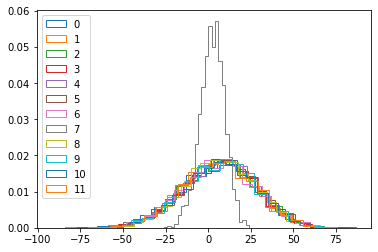

0.0030715014369617766


In [9]:
print("NGC P+B FKP p=1")
hist_chain(np.load("bis-fits/output-PplusB-s3rebin/NGC/mocks-SNsub/fkp/1.0/chain.npy"))

In [10]:
chain = np.load(output + "NGC/mocks-SNsub/fkp/1.0/chain.npy")

f_nl_chain = chain[:,0,:]

f_nl_chain = np.delete(f_nl_chain, [7,], 1)

R = pp.gelman_rubin_R(f_nl_chain)

print("NGC FKP p=1")
print(R - 1)

print(pp.confidence_interval(f_nl_chain.flatten(), 0.68))
print(pp.confidence_interval(f_nl_chain.flatten(), 0.95))

NGC FKP p=1
0.00022049010427149796
[-14.30197613  28.6813    ]
[-37.88839547  47.37957814]


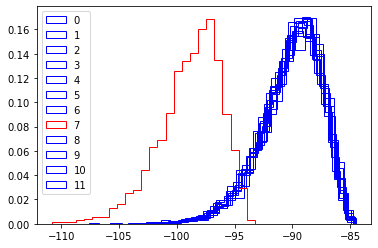

In [11]:
like = chain[:,14,:]

for i in range(12):
    if i in [7,]: color = 'r'
    else: color = 'b'
    plt.hist(like[:,i], bins=25, density=True, histtype='step', label=f'{i}', color=color)

plt.legend()
plt.show()

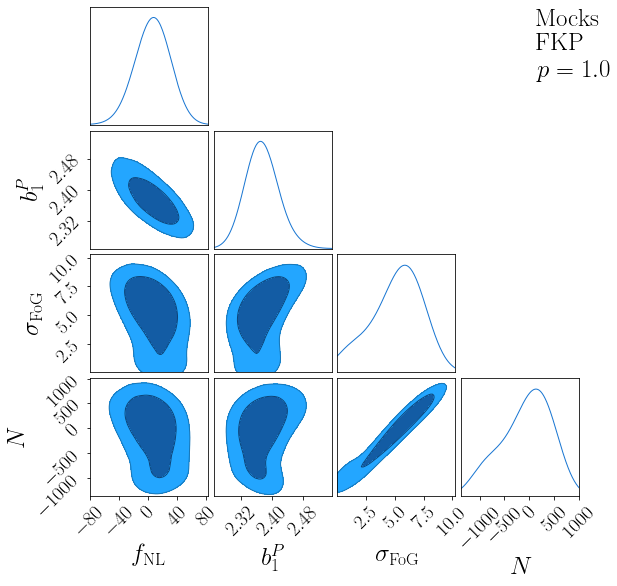

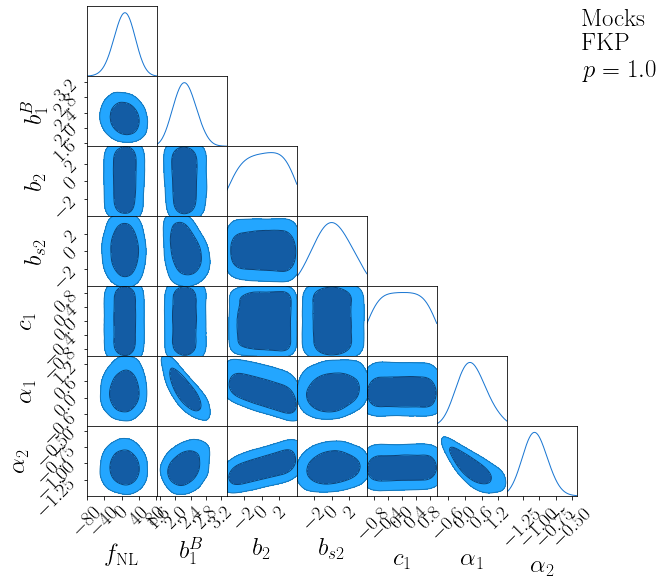

In [12]:
chain = np.load(output + "NGC/mocks-SNsub/fkp/1.0/chain.npy")
plot_corner_PplusB(chain, "N", pop = [7,], save = None,
                  annotate="${\\rm Mocks}$ \n ${\\rm FKP}$ \n $p=1.0$", xy=(75, 420),
                  limits=None)

## MOCKS: NGC constant noise subtraction optimal P p=1 

NGC P+B p=1


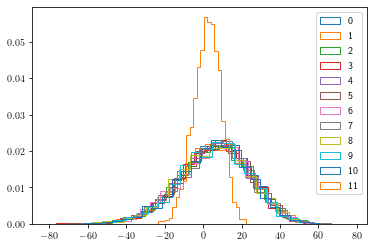

0.003246252753790868


In [13]:
print("NGC P+B p=1")
hist_chain(np.load("bis-fits/output-PplusB-s3rebin/NGC/mocks-SNsub/1.0/chain.npy"))

In [14]:
chain = np.load(output + "NGC/mocks-SNsub/1.0/chain.npy")

f_nl_chain = chain[:,0,:]

f_nl_chain = np.delete(f_nl_chain, [11,], 1)

R = pp.gelman_rubin_R(f_nl_chain)

print("NGC p=1")
print(R - 1)

print(pp.confidence_interval(f_nl_chain.flatten(), 0.68))
print(pp.confidence_interval(f_nl_chain.flatten(), 0.95))

NGC p=1
-2.8248652852336242e-05
[-11.36967547  25.05537403]
[-31.15386982  40.9873634 ]


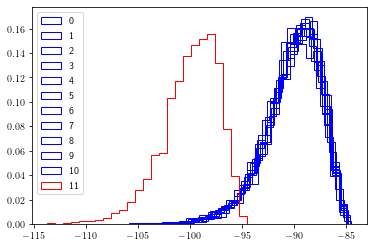

In [15]:
like = chain[:,14,:]

for i in range(12):
    if i in [11,]: color = 'r'
    else: color = 'b'
    plt.hist(like[:,i], bins=25, density=True, histtype='step', label=f'{i}', color=color)

plt.legend()
plt.show()

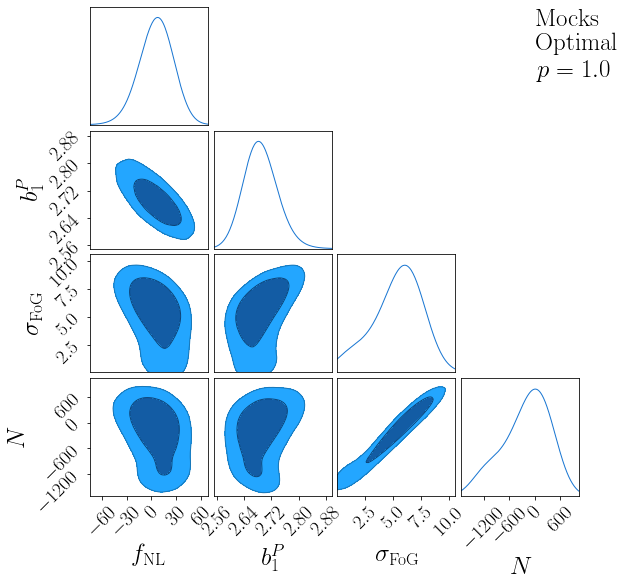

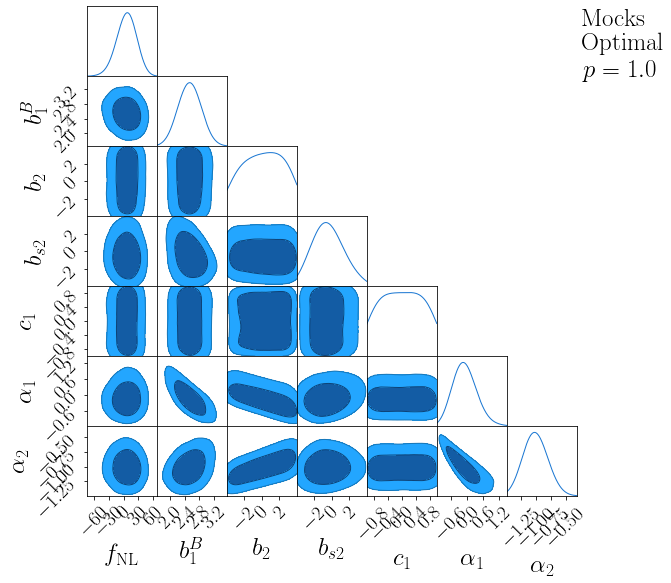

In [16]:
chain = np.load(output + "NGC/mocks-SNsub/1.0/chain.npy")
plot_corner_PplusB(chain, "N", pop = [11,], save = None,
                  annotate="${\\rm Mocks}$ \n ${\\rm Optimal}$ \n $p=1.0$", xy=(75, 420),
                  limits=None)

## MOCKS: NGC constant noise subtraction FKP p=1.6

In [17]:
output = "bis-fits/output-PplusB-s3rebin/"

NGC P+B FKP p=1.6


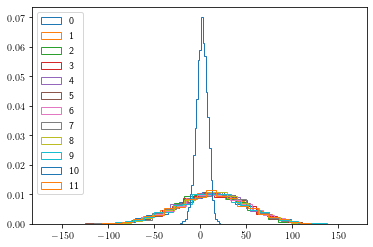

0.007637004305381723


In [18]:
print("NGC P+B FKP p=1.6")
hist_chain(np.load("bis-fits/output-PplusB-s3rebin/NGC/mocks-SNsub/fkp/1.6/chain.npy"))

In [19]:
chain = np.load(output + "NGC/mocks-SNsub/fkp/1.6/chain.npy")

f_nl_chain = chain[:,0,:]

f_nl_chain = np.delete(f_nl_chain, [10,], 1)

R = pp.gelman_rubin_R(f_nl_chain)

print("NGC FKP p=1.6")
print(R - 1)

print(pp.confidence_interval(f_nl_chain.flatten(), 0.68))
print(pp.confidence_interval(f_nl_chain.flatten(), 0.95))

NGC FKP p=1.6
0.0007715775051637674
[-22.95694371  53.82243429]
[-63.8603979   89.35568294]


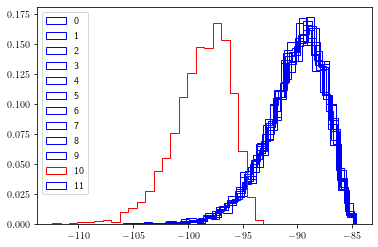

In [20]:
like = chain[:,14,:]

for i in range(12):
    if i in [10,]: color = 'r'
    else: color = 'b'
    plt.hist(like[:,i], bins=25, density=True, histtype='step', label=f'{i}', color=color)

plt.legend()
plt.show()

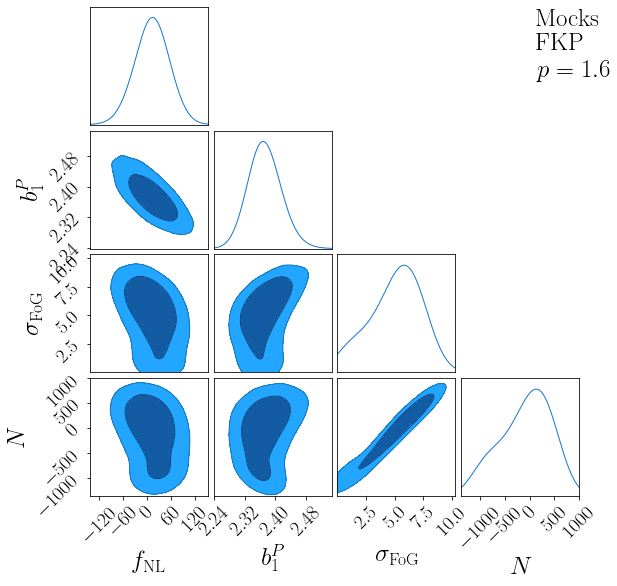

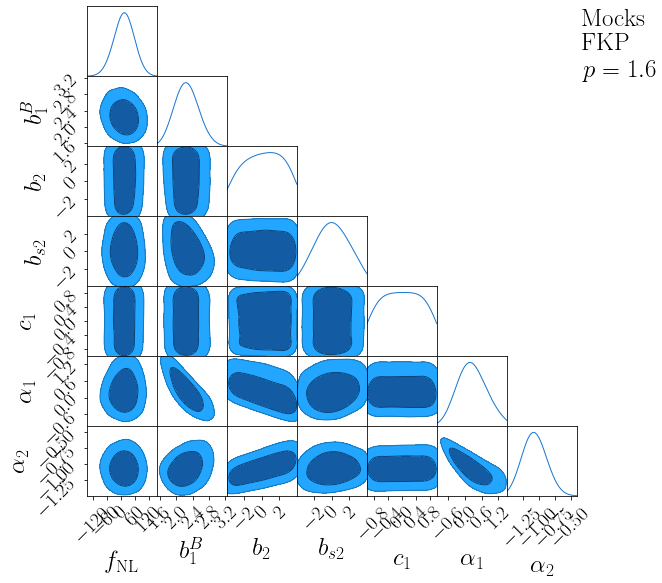

In [21]:
chain = np.load(output + "NGC/mocks-SNsub/fkp/1.6/chain.npy")
plot_corner_PplusB(chain, "N", pop = [10,], save = None,
                  annotate="${\\rm Mocks}$ \n ${\\rm FKP}$ \n $p=1.6$", xy=(75, 420),
                  limits=None)

## MOCKS: NGC constant noise subtraction optimal P p=1.6

NGC P+B p=1


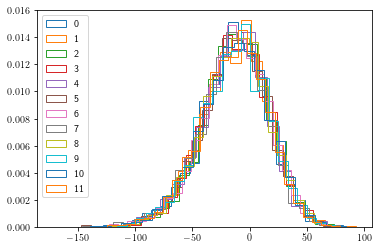

0.0004442445647352411


In [22]:
print("NGC P+B p=1")
hist_chain(np.load("bis-fits/output-PplusB-s3rebin/NGC/mocks-SNsub/1.6/chain.npy"))

In [23]:
chain = np.load(output + "NGC/mocks-SNsub/1.6/chain.npy")

f_nl_chain = chain[:,0,:]

#f_nl_chain = np.delete(f_nl_chain, [9,], 1)

R = pp.gelman_rubin_R(f_nl_chain)

print("NGC p=1")
print(R - 1)

print(pp.confidence_interval(f_nl_chain.flatten(), 0.68))
print(pp.confidence_interval(f_nl_chain.flatten(), 0.95))

NGC p=1
0.0004442445647352411
[-38.76835977  17.90852726]
[-71.73369959  42.89091855]


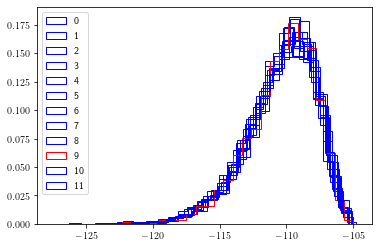

In [24]:
like = chain[:,14,:]

for i in range(12):
    if i in [9,]: color = 'r'
    else: color = 'b'
    plt.hist(like[:,i], bins=25, density=True, histtype='step', label=f'{i}', color=color)

plt.legend()
plt.show()

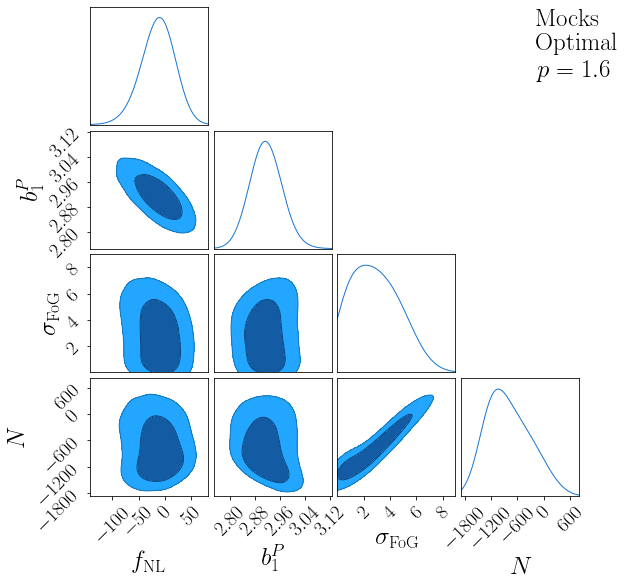

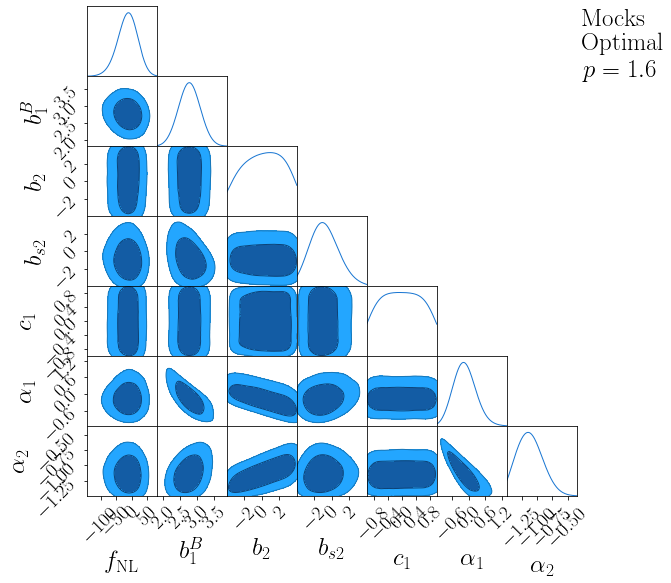

In [25]:
chain = np.load(output + "NGC/mocks-SNsub/1.6/chain.npy")
plot_corner_PplusB(chain, "N", pop = None, save = None,
                  annotate="${\\rm Mocks}$ \n ${\\rm Optimal}$ \n $p=1.6$", xy=(75, 420),
                  limits=None)

# No window and no IC

## MOCKS: NGC constant noise subtraction FKP p=1

In [5]:
output = "bis-fits/output-PplusB-s3rebin/"

NGC P+B FKP p=1


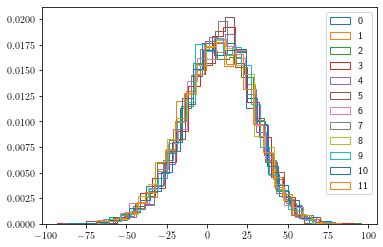

0.00020176743983113532


In [27]:
print("NGC P+B FKP p=1")
hist_chain(np.load("bis-fits/output-PplusB-s3rebin/NGC/mocks-SNsub-noW-noIC/fkp/1.0/chain.npy"))

In [28]:
chain = np.load(output + "NGC/mocks-SNsub-noW-noIC/fkp/1.0/chain.npy")

f_nl_chain = chain[:,0,:]

#f_nl_chain = np.delete(f_nl_chain, [11,7,], 1)

R = pp.gelman_rubin_R(f_nl_chain)

print("NGC FKP p=1")
print(R - 1)

print(pp.confidence_interval(f_nl_chain.flatten(), 0.68))
print(pp.confidence_interval(f_nl_chain.flatten(), 0.95))

NGC FKP p=1
0.00020176743983113532
[-13.71126137  29.37468282]
[-35.33543243  50.6407356 ]


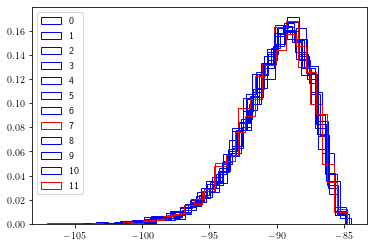

In [29]:
like = chain[:,14,:]

for i in range(12):
    if i in [7,11,]: color = 'r'
    else: color = 'b'
    plt.hist(like[:,i], bins=25, density=True, histtype='step', label=f'{i}', color=color)

plt.legend()
plt.show()

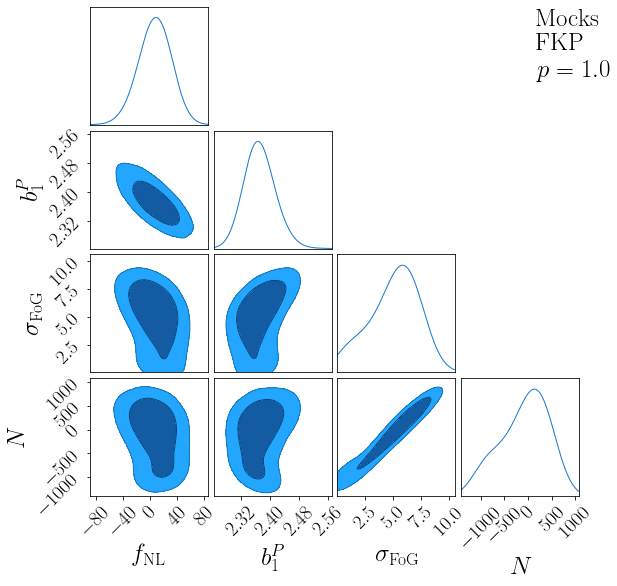

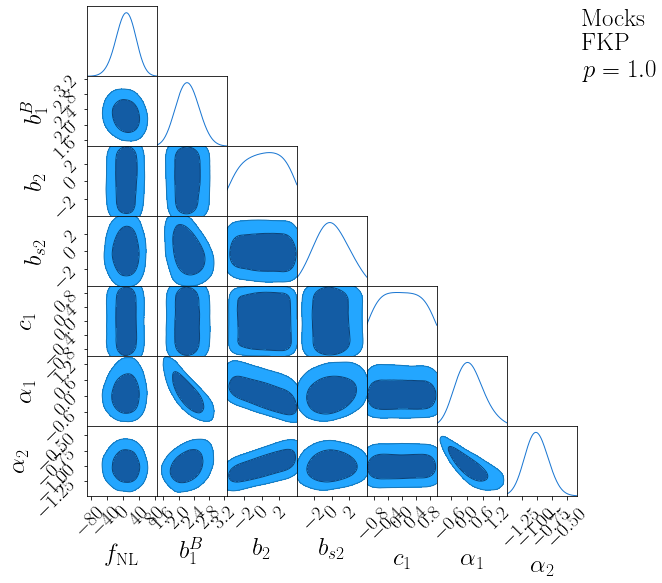

In [30]:
chain = np.load(output + "NGC/mocks-SNsub-noW-noIC/fkp/1.0/chain.npy")
plot_corner_PplusB(chain, "N", pop = None, save = None,
                  annotate="${\\rm Mocks}$ \n ${\\rm FKP}$ \n $p=1.0$", xy=(75, 420),
                  limits=None)

## DATA: NGC constant noise subtraction optimal P p=1

NGC P+B p=1


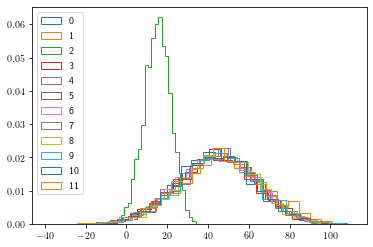

0.21195343368503283


In [31]:
print("NGC P+B p=1")
hist_chain(np.load("bis-fits/output-PplusB-s3rebin/NGC/data-SNsub-noW-noIC/fkp/1.0/chain.npy"))

In [32]:
chain = np.load(output + "NGC/data-SNsub-noW-noIC/fkp/1.0/chain.npy")

f_nl_chain = chain[:,0,:]

f_nl_chain = np.delete(f_nl_chain, [2,], 1)

R = pp.gelman_rubin_R(f_nl_chain)

print("NGC p=1")
print(R - 1)

print(pp.confidence_interval(f_nl_chain.flatten(), 0.68))
print(pp.confidence_interval(f_nl_chain.flatten(), 0.95))

NGC p=1
0.002454006072502679
[26.1255803  64.23685233]
[ 6.77913001 82.19980077]


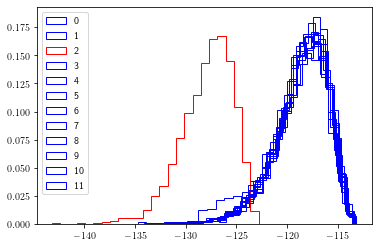

In [33]:
like = chain[:,14,:]

for i in range(12):
    if i in [2,]: color = 'r'
    else: color = 'b'
    plt.hist(like[:,i], bins=25, density=True, histtype='step', label=f'{i}', color=color)

plt.legend()
plt.show()

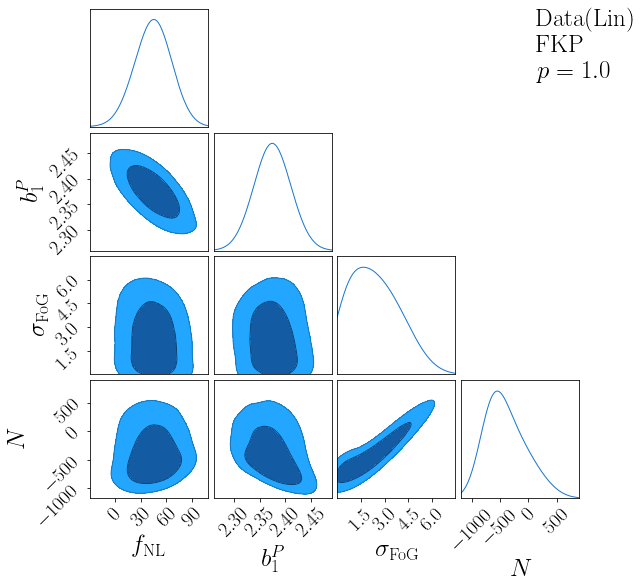

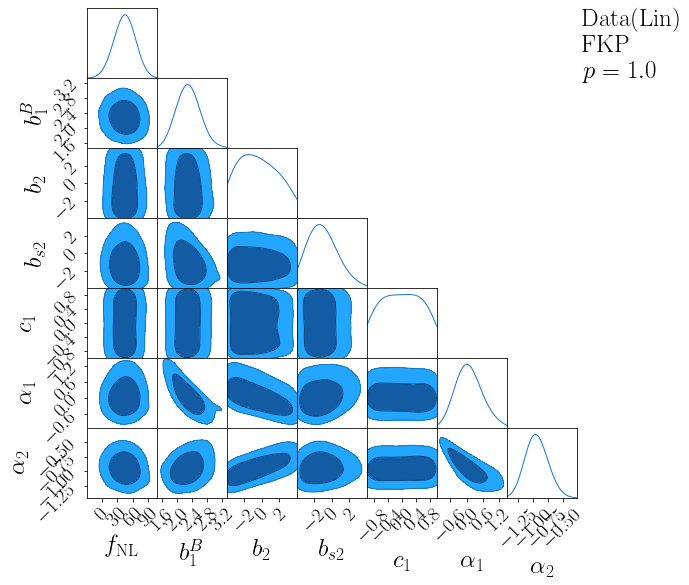

In [34]:
chain = np.load(output + "NGC/data-SNsub-noW-noIC/fkp/1.0/chain.npy")
plot_corner_PplusB(chain, "N", pop = [2,], save = None,
                  annotate="${\\rm Data (Lin)}$ \n ${\\rm FKP}$ \n $p=1.0$", xy=(75, 420),
                  limits=None)

## Compare with and w/o window and IC

### MOCKS: FKP p=1.0

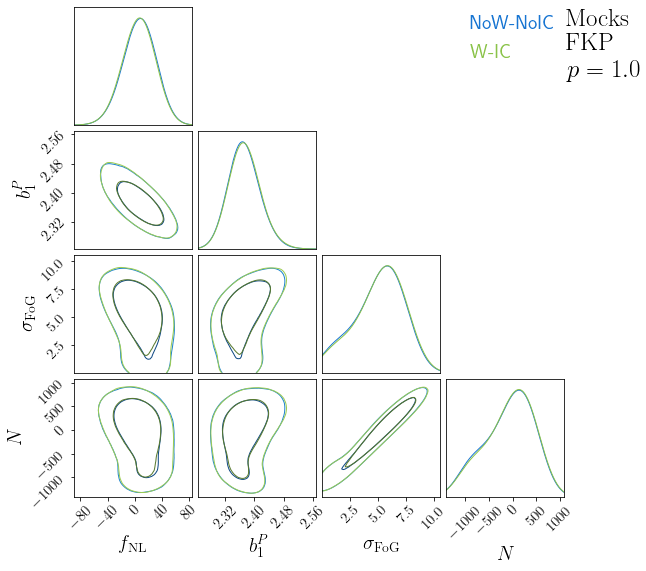

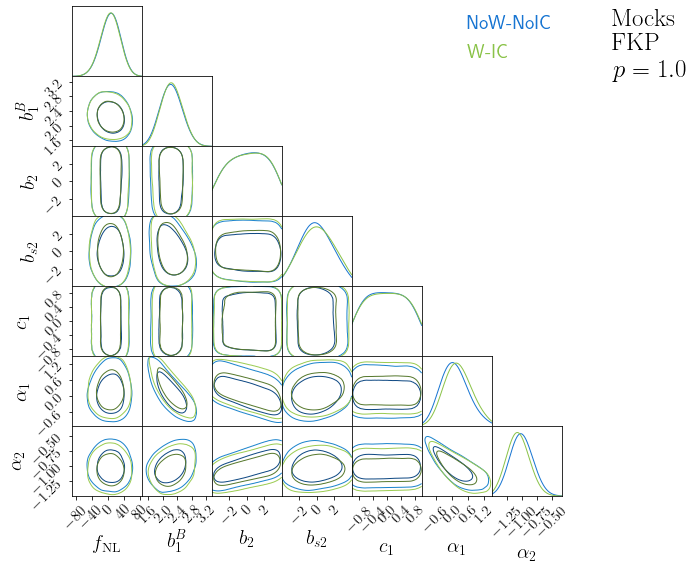

In [6]:
chain1 = np.load(output + "NGC/mocks-SNsub-noW-noIC/fkp/1.0/chain.npy")
chain2 = np.load(output + "NGC/mocks-SNsub/fkp/1.0/chain.npy")

plot_corner_PplusB_compare(chain1, chain2, "N", label1="NoW-NoIC", label2="W-IC", pop2 = [7,], save = None,
                  annotate="${\\rm Mocks}$ \n ${\\rm FKP}$ \n $p=1.0$", xy=(120, 420),
                  limits=None)

INFO:matplotlib.texmanager:No LaTeX-compatible font found for the serif font family in rcParams. Using default.
INFO:matplotlib.texmanager:No LaTeX-compatible font found for the serif font family in rcParams. Using default.
INFO:matplotlib.texmanager:No LaTeX-compatible font found for the serif font family in rcParams. Using default.
INFO:matplotlib.texmanager:No LaTeX-compatible font found for the serif font family in rcParams. Using default.
INFO:matplotlib.texmanager:No LaTeX-compatible font found for the serif font family in rcParams. Using default.
INFO:matplotlib.texmanager:No LaTeX-compatible font found for the serif font family in rcParams. Using default.
INFO:matplotlib.texmanager:No LaTeX-compatible font found for the serif font family in rcParams. Using default.
INFO:matplotlib.texmanager:No LaTeX-compatible font found for the serif font family in rcParams. Using default.
INFO:matplotlib.texmanager:No LaTeX-compatible font found for the serif font family in rcParams. Using d

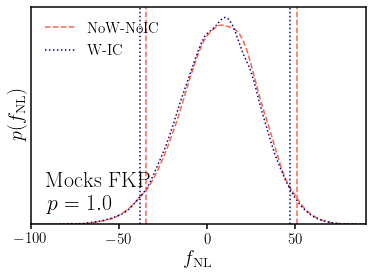

In [10]:
chain1 = np.load(output + "NGC/mocks-SNsub-noW-noIC/fkp/1.0/chain.npy")
chain2 = np.load(output + "NGC/mocks-SNsub/fkp/1.0/chain.npy")

f_nl_chain1 = chain1[:,0,:]
f_nl_chain1 = np.delete(f_nl_chain1, [2,], 1)

f_nl_chain2 = chain2[:,0,:]
f_nl_chain2 = np.delete(f_nl_chain2, [7,], 1)

ci95 = np.array([[-35,51],[-38,47]])

fNL_posterior_comparison_smooth(f_nl_chain1, f_nl_chain2, name1='NoW-NoIC', name2='W-IC', save=None, ci95=ci95,
                               annotate="Mocks FKP \n $p=1.0$", xy=(15,15), xlim=[-100, 90])

### DATA: FKP p=1.0

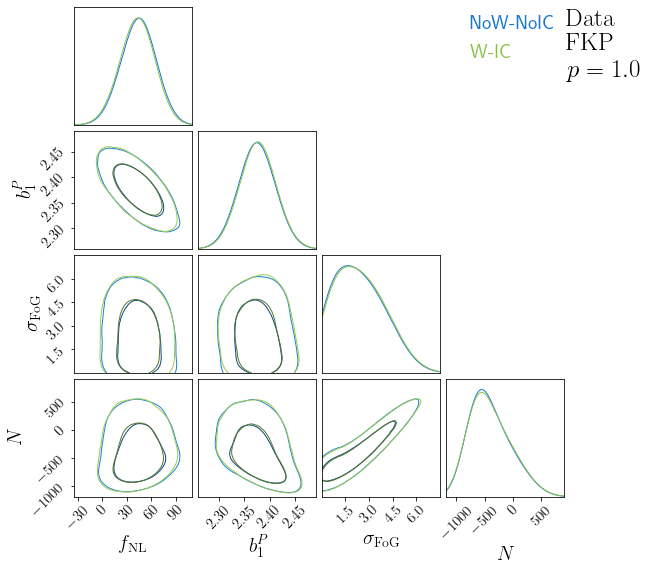

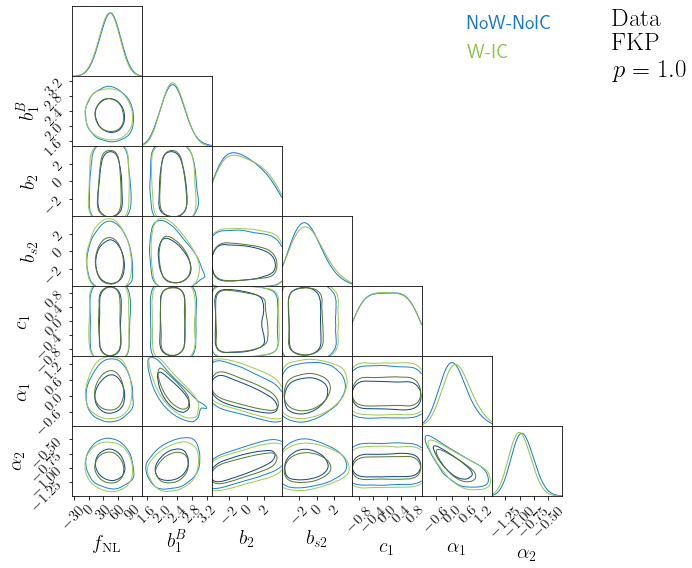

In [41]:
chain1 = np.load(output + "NGC/data-SNsub-noW-noIC/fkp/1.0/chain.npy")
chain2 = np.load(output + "NGC/data-SNsub/fkp/1.0/chain.npy")

plot_corner_PplusB_compare(chain1, chain2, "N", label1="NoW-NoIC", label2="W-IC", pop1=[2,], pop2 = [7,], save = None,
                  annotate="${\\rm Data}$ \n ${\\rm FKP}$ \n $p=1.0$", xy=(120, 420),
                  limits=None)

INFO:matplotlib.texmanager:No LaTeX-compatible font found for the serif font family in rcParams. Using default.
INFO:matplotlib.texmanager:No LaTeX-compatible font found for the serif font family in rcParams. Using default.
INFO:matplotlib.texmanager:No LaTeX-compatible font found for the serif font family in rcParams. Using default.
INFO:matplotlib.texmanager:No LaTeX-compatible font found for the serif font family in rcParams. Using default.
INFO:matplotlib.texmanager:No LaTeX-compatible font found for the serif font family in rcParams. Using default.
INFO:matplotlib.texmanager:No LaTeX-compatible font found for the serif font family in rcParams. Using default.
INFO:matplotlib.texmanager:No LaTeX-compatible font found for the serif font family in rcParams. Using default.
INFO:matplotlib.texmanager:No LaTeX-compatible font found for the serif font family in rcParams. Using default.
INFO:matplotlib.texmanager:No LaTeX-compatible font found for the serif font family in rcParams. Using d

INFO:matplotlib.texmanager:No LaTeX-compatible font found for the serif font family in rcParams. Using default.
INFO:matplotlib.texmanager:No LaTeX-compatible font found for the serif font family in rcParams. Using default.
INFO:matplotlib.texmanager:No LaTeX-compatible font found for the serif font family in rcParams. Using default.
INFO:matplotlib.texmanager:No LaTeX-compatible font found for the serif font family in rcParams. Using default.
INFO:matplotlib.texmanager:No LaTeX-compatible font found for the serif font family in rcParams. Using default.
INFO:matplotlib.texmanager:No LaTeX-compatible font found for the serif font family in rcParams. Using default.
INFO:matplotlib.texmanager:No LaTeX-compatible font found for the serif font family in rcParams. Using default.


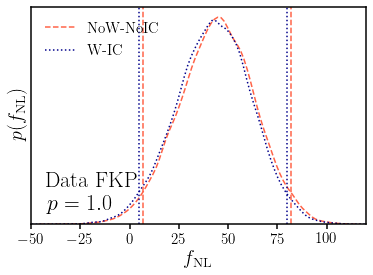

In [11]:
chain1 = np.load(output + "NGC/data-SNsub-noW-noIC/fkp/1.0/chain.npy")
chain2 = np.load(output + "NGC/data-SNsub/fkp/1.0/chain.npy")

f_nl_chain1 = chain1[:,0,:]
f_nl_chain1 = np.delete(f_nl_chain1, [2,], 1)

f_nl_chain2 = chain2[:,0,:]
f_nl_chain2 = np.delete(f_nl_chain2, [7,], 1)

ci95 = np.array([[7,82],[5,80]])

fNL_posterior_comparison_smooth(f_nl_chain1, f_nl_chain2, name1='NoW-NoIC', name2='W-IC', save=None, ci95=ci95,
                               annotate="Data FKP \n $p=1.0$", xy=(15,15), xlim=[-50, 120])